# Обучение без учителя

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Кластеризация

Кластеризация – одна из самых популярных задач обучения без учителя. Её цель – разбить набор
объектов на группы (кластеры) так, чтобы объекты внутри одной группы были похожи друг на друга,
а объекты из разных групп – максимально различались.

Ты будешь работать с реальными геоданными: данные о посещениях заведений из сервиса Foursquare.
Задача – помочь американской туристической компании найти оптимальные места для размещения
рекламных баннеров рядом с офисами продаж.

![banner](../../production/AI_Machine_Learning.Project_5.ID_1577775/misc/images/banner.png)

### Задание 1. Загрузка и подготовка данных

Ты работаешь в американской туристической компании. Компания хочет разместить рекламные баннеры
рядом со своими офисами в местах с наибольшим потоком посетителей. Для этого у тебя есть данные
о регистрации пользователей в заведениях и геолокация этих заведений.

1. Загрузи данные о посещениях заведений из файла `../datasets/checkins.dat`.
   Очисти данные от записей с пропусками. Выведи количество записей после очистки.
2. С помощью библиотеки [Reverse Geocoder](https://github.com/thampiman/reverse-geocoder) определи
   страну для каждой геопозиции. Узнай **название** второй страны по количеству записей.
3. Оставь только американские локации. Оставь только 50 самых часто встречаемых заведений
   (venue). Выведи количество оставшихся записей.

In [2]:
filepath = "../../production/AI_Machine_Learning.Project_5.ID_1577775/datasets/checkins.dat"
data = pd.read_csv(filepath, sep="|", skipinitialspace=True)
data.columns = ["id", "user_id", "venue_id", "latitude", "longitude", "created_at"]

/var/folders/07/935mwg8x6bl2x3z6x_7wc7kc0000gn/T/ipykernel_54856/2995828742.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filepath, sep="|", skipinitialspace=True)


In [3]:
data = data.dropna()
data = data.set_index("id")
print(f"Записей после очистки: {len(data)}")  # 396634

Записей после очистки: 396634


In [4]:
import reverse_geocoder as rg

In [5]:
results = rg.search(list(data[["latitude", "longitude"]].itertuples(index=False, name=None)))
data["country"] = [row["cc"] for row in results]
print(data["country"].value_counts().head(5))  # US, ID, CA, GB, MX
# Вторая страна: Индонезия (ID)

Loading formatted geocoded file...
country
US    373258
ID      5356
CA      5341
GB      1812
MX       833
Name: count, dtype: int64


In [6]:
data = data[data["country"] == "US"]
top_venues = data["venue_id"].value_counts().iloc[:50].index
data = data[data["venue_id"].isin(top_venues)]
print(f"Записей после фильтрации: {len(data)}")  # 162099

Записей после фильтрации: 162099


### Задание 2. Кластеризация методом MeanShift

Центры полученных кластеров – это «типичные» точки концентрации посещений, то есть кандидаты на места
установки баннеров. Твоя цель – сопоставить эти кандидаты с офисами продаж: для каждого офиса посчитать
расстояния до центров кластеров и выбрать те центры, которые находятся ближе всего к офису.

1. Примени алгоритм [MeanShift](https://scikit-learn.org/stable/modules/clustering.html#mean-shift)
   для кластеризации геолокаций. Параметры: `MeanShift(bandwidth=0.1, bin_seeding=True)`.

       `bandwidth=0.1` – ширина ядра (радиус «окрестности»), внутри которой точки считаются близкими и
       начинают объединяться в один кластер. В этой задаче координаты заданы в градусах, поэтому 0.1°
       соответствует примерно 8–11 км (зависит от широты и направления). Чем больше bandwidth, тем меньше
       кластеров и тем они «крупнее»; чем меньше – тем кластеров больше и они локальнее.
       `bin_seeding=True` – для ускорения работы алгоритма.

   Выведи количество кластеров.
2. Загрузи [данные по координатам офисов компании](../datasets/offices.csv). Для каждого офиса
   найди 5 самых ближайших центров кластеров (евклидово расстояние). У компании 11 офисов,
   значит должно получиться 55 мест установки баннеров.
3. Выведи координаты установки баннера, который ближе всего находится к офису компании.
4. С помощью функции
   [scatter_map](https://plotly.com/python-api-reference/generated/plotly.express.scatter_map.html)
   отметь 55 точек установки баннеров на карте. Цветом обозначь, к какому офису относится баннер.

In [7]:
from sklearn.cluster import MeanShift
from scipy.spatial.distance import euclidean

In [8]:
clustering = MeanShift(bandwidth=0.1, bin_seeding=True).fit(data[["latitude", "longitude"]])
clusters = pd.DataFrame(clustering.cluster_centers_, columns=["latitude", "longitude"])
print(f"Количество кластеров: {len(clusters)}")  # 2846

Количество кластеров: 2846


In [9]:
offices = pd.read_csv("../../production/AI_Machine_Learning.Project_5.ID_1577775/datasets/offices.csv", index_col=0)

index_office = []
min_dist = []
for point in clusters.values:
    dists = [euclidean(point, office) for office in offices.values]
    index_office.append(np.argmin(dists))
    min_dist.append(np.min(dists))

clusters["index_office"] = index_office
clusters["min_dist"] = min_dist

for_plot = clusters.sort_values("min_dist").groupby("index_office").head(5)
for_plot["index_office"] = for_plot["index_office"].astype(str)
print(for_plot.head(1))  # (32.785318, -79.924742)

      latitude  longitude index_office  min_dist
112  32.785318 -79.924742            9  0.004092


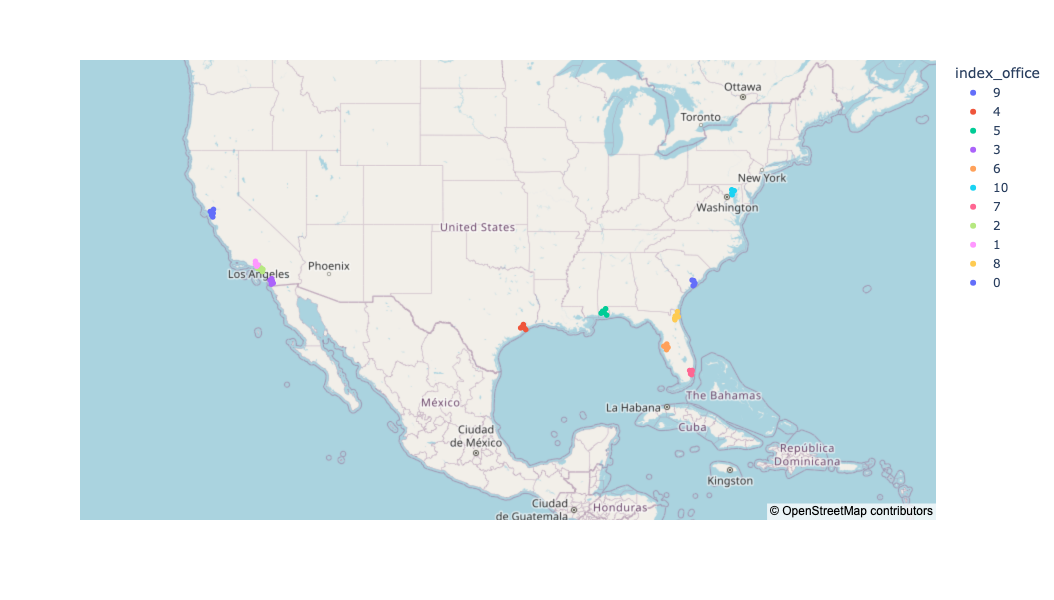

In [10]:
import plotly.express as px

fig = px.scatter_map(for_plot, lat="latitude", lon="longitude", color="index_office",
                     zoom=3, height=600, width=800)
fig.update_layout(map_style="open-street-map")
fig.show()

### Задание 3. KMeans и Silhouette Score

Дальше ты воспользуешься ещё одним методом кластеризации – KMeans – и сравнишь его с MeanShift.
Для KMeans нужно заранее выбрать число кластеров k – обычно его оценивают методом локтя (Elbow Method):
построй график зависимости inertia от k и найди «излом», после которого дальнейшее увеличение k даёт
лишь небольшой выигрыш.

Чтобы сравнение было объективным, используй Silhouette Score – метрику качества кластеризации:
чем ближе значение к 1, тем лучше; около 0 – кластеры сильно перекрываются; меньше 0 – точки чаще
оказываются ближе к «чужому» кластеру, чем к своему.

1. Примени алгоритм KMeans к тем же данным (координатам локаций из задания 1). Используй метод
   локтя (Elbow Method) для выбора оптимального числа кластеров: построй график инерции
   (inertia) для k от 2 до 50. Выбери k и обучи финальную модель.
2. Сравни результаты MeanShift и KMeans: вычисли Silhouette Score для обоих алгоритмов. Какой
   алгоритм лучше подходит для данной задачи и почему?

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

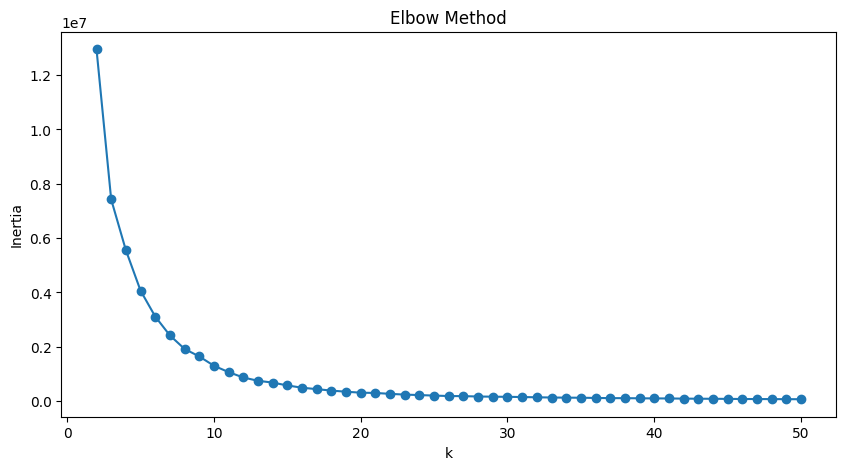

In [12]:
coords = data[["latitude", "longitude"]].values

inertias = []
K_range = range(2, 51)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [13]:
km_model = KMeans(n_clusters=20, random_state=42, n_init=10).fit(coords)

sil_kmeans = silhouette_score(coords, km_model.labels_, sample_size=10000, random_state=42)
sil_ms = silhouette_score(coords, clustering.labels_, sample_size=10000, random_state=42)

print(f"Silhouette KMeans: {sil_kmeans:.4f}")
print(f"Silhouette MeanShift: {sil_ms:.4f}")

Silhouette KMeans: 0.7241
Silhouette MeanShift: 0.7210


**Вывод по заданию 3.**

По значениям Silhouette Score в данном решении `KMeans` показывает немного более высокое качество,
чем `MeanShift`. Для этой задачи это означает, что выбранное `k` даёт более компактные и лучше
разделённые кластеры; при этом `MeanShift` остаётся полезным, когда число кластеров заранее неизвестно.

## Понижение размерности

Реальные данные часто имеют сотни и тысячи признаков. Работать с такими данными сложно:
визуализировать их нельзя, модели обучаются медленно, а многие признаки могут быть
коррелированными или шумовыми. Методы понижения размерности сжимают данные до меньшего числа
компонент, сохраняя при этом максимум полезной информации.

Три основных подхода:

- **PCA (Principal Component Analysis)** – линейный метод, который находит направления
  максимальной дисперсии в данных. Главное преимущество – интерпретируемость: можно оценить,
  сколько информации сохраняется при сжатии, и восстановить данные из сжатого представления.
- **t-SNE (t-distributed Stochastic Neighbor Embedding)** – нелинейный метод, оптимизированный
  для визуализации. Сохраняет локальную структуру данных (близкие точки остаются близкими),
  но не сохраняет глобальные расстояния.
- **UMAP (Uniform Manifold Approximation and Projection)** – нелинейный метод, который сочетает
  преимущества t-SNE (качество визуализации) с лучшей масштабируемостью и сохранением
  глобальной структуры данных.

![mnist](../../production/AI_Machine_Learning.Project_5.ID_1577775/misc/images/mnist.png)

Ты будешь работать датасетом MNIST. Это 70 000 изображений рукописных цифр 28×28 (10 классов), где каждое изображение
представлено вектором из 784 признаков. Такая высокая размерность делает MNIST показательным для задачи понижения размерности: после проекции легче увидеть структуру классов и сравнить
качество методов.

### Задание 4. Загрузка и предобработка MNIST

1. Загрузи датасет MNIST с помощью `torchvision.datasets.MNIST`. Возьми случайную
   подвыборку из 5000 изображений (`random_state=42`), стратифицированную по классам
   (по 500 изображений на цифру). Покажи, что подвыборка стратифицирована.
2. Покажи сетку примеров: по одному изображению из каждого класса с подписью цифры.
3. «Разверни» изображения из 28×28 в вектор длины 784. Стандартизируй данные
   с помощью `StandardScaler`.
4. Выведи размерность датасета.

In [15]:
import torchvision
from sklearn.preprocessing import StandardScaler

In [16]:
dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True)

In [17]:
X_full = np.array(dataset.data)  # (60000, 28, 28)
y_full = np.array(dataset.targets);

/var/folders/07/935mwg8x6bl2x3z6x_7wc7kc0000gn/T/ipykernel_54856/3827623172.py:1: DeprecationWarning:

__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword

/var/folders/07/935mwg8x6bl2x3z6x_7wc7kc0000gn/T/ipykernel_54856/3827623172.py:2: DeprecationWarning:

__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword



In [18]:
class_names = [str(i) for i in range(10)]

In [19]:
rng = np.random.default_rng(42)
indices = []
for cls in range(10):
    cls_idx = np.where(y_full == cls)[0]
    sampled = rng.choice(cls_idx, size=500, replace=False)
    indices.append(sampled)
indices = np.concatenate(indices)
rng.shuffle(indices)

In [20]:
X_sub = X_full[indices]
y_sub = y_full[indices]

print(f"Подвыборка: {X_sub.shape}, классов: {len(np.unique(y_sub))}")
print(f"Распределение: {np.bincount(y_sub)}")

Подвыборка: (5000, 28, 28), классов: 10
Распределение: [500 500 500 500 500 500 500 500 500 500]


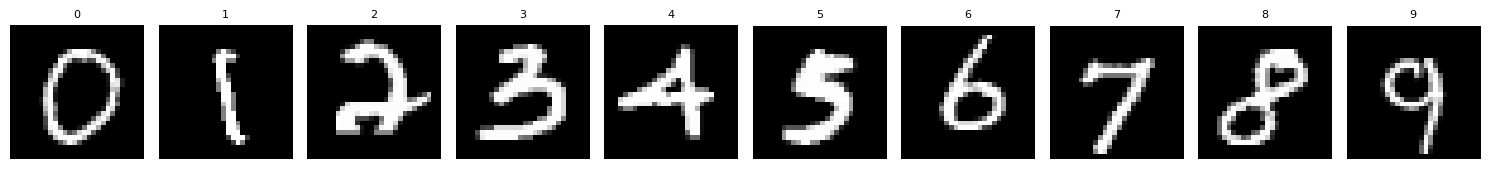

In [21]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, cls in enumerate(range(10)):
    idx = np.where(y_sub == cls)[0][0]
    axes[i].imshow(X_sub[idx], cmap="gray")
    axes[i].set_title(class_names[cls], fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [22]:
X_flat = X_sub.reshape(len(X_sub), -1).astype(np.float64)  # (5000, 784)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

In [23]:
print(f"Форма: {X_scaled.shape}")

Форма: (5000, 784)


In [24]:
X_scaled.mean()

np.float64(1.3920837272034617e-18)

In [25]:
X_scaled.std()

np.float64(0.9161253813129052)

### Задание 5. Метод главных компонент (PCA)

**Ответы по заданию 5.**

В 3D-проекции PCA классы MNIST разделяются лучше, чем сложные цветные изображения, но всё равно
часть цифр перекрывается. Обычно лучше отделяются 0, 1 и 6, а хуже – пары со схожим начертанием,
например 3/5 и 8/9. По реконструкциям: при n=10 изображение размыто, при n=50 хорошо виден контур,
при n=100 цифра уверенно узнаваема, при n=200 качество близко к оригиналу.

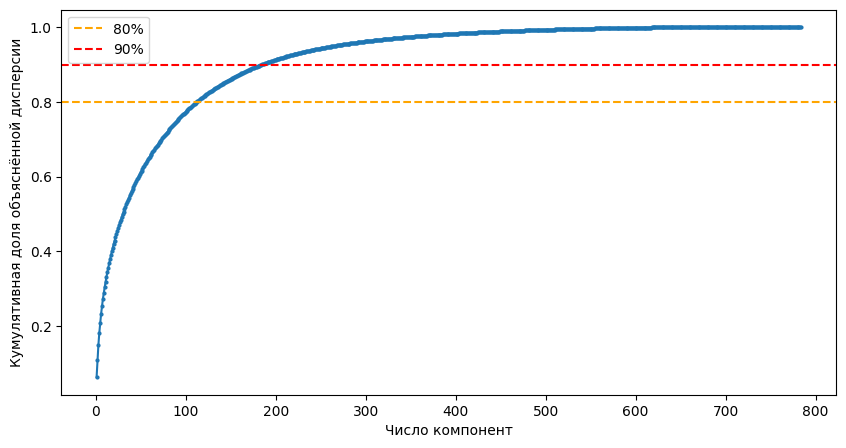

Компонент для 80% дисперсии: 113
Компонент для 90% дисперсии: 185


In [26]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker="o", markersize=2)
plt.axhline(y=0.8, color="orange", linestyle="--", label="80%")
plt.axhline(y=0.9, color="r", linestyle="--", label="90%")
plt.xlabel("Число компонент")
plt.ylabel("Кумулятивная доля объяснённой дисперсии")
plt.legend()
plt.show()

n_80 = np.argmax(cumvar >= 0.8) + 1
n_90 = np.argmax(cumvar >= 0.9) + 1
print(f"Компонент для 80% дисперсии: {n_80}")
print(f"Компонент для 90% дисперсии: {n_90}")

In [27]:
import plotly.express as px

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "PC3": X_pca[:, 2],
    "class": [class_names[c] for c in y_sub]
})
fig = px.scatter_3d(pca_df, x="PC1", y="PC2", z="PC3", color="class",
                    opacity=0.7, height=600, width=800,
                    title="PCA: первые 3 компоненты (MNIST)")
fig.update_traces(marker_size=3)
fig.show()

**Ответы по заданию 6.**

- `Perplexity` регулирует баланс между локальной и глобальной структурой: малые значения сильнее
  фокусируются на локальных соседях, большие – сглаживают картину.
- Для MNIST обычно лучший визуальный баланс даёт `perplexity=30`.
- t-SNE даёт более чёткие визуальные кластеры, чем PCA, потому что это нелинейный метод,
  сохраняющий локальные соседства, тогда как PCA линейно проецирует по глобальной дисперсии.

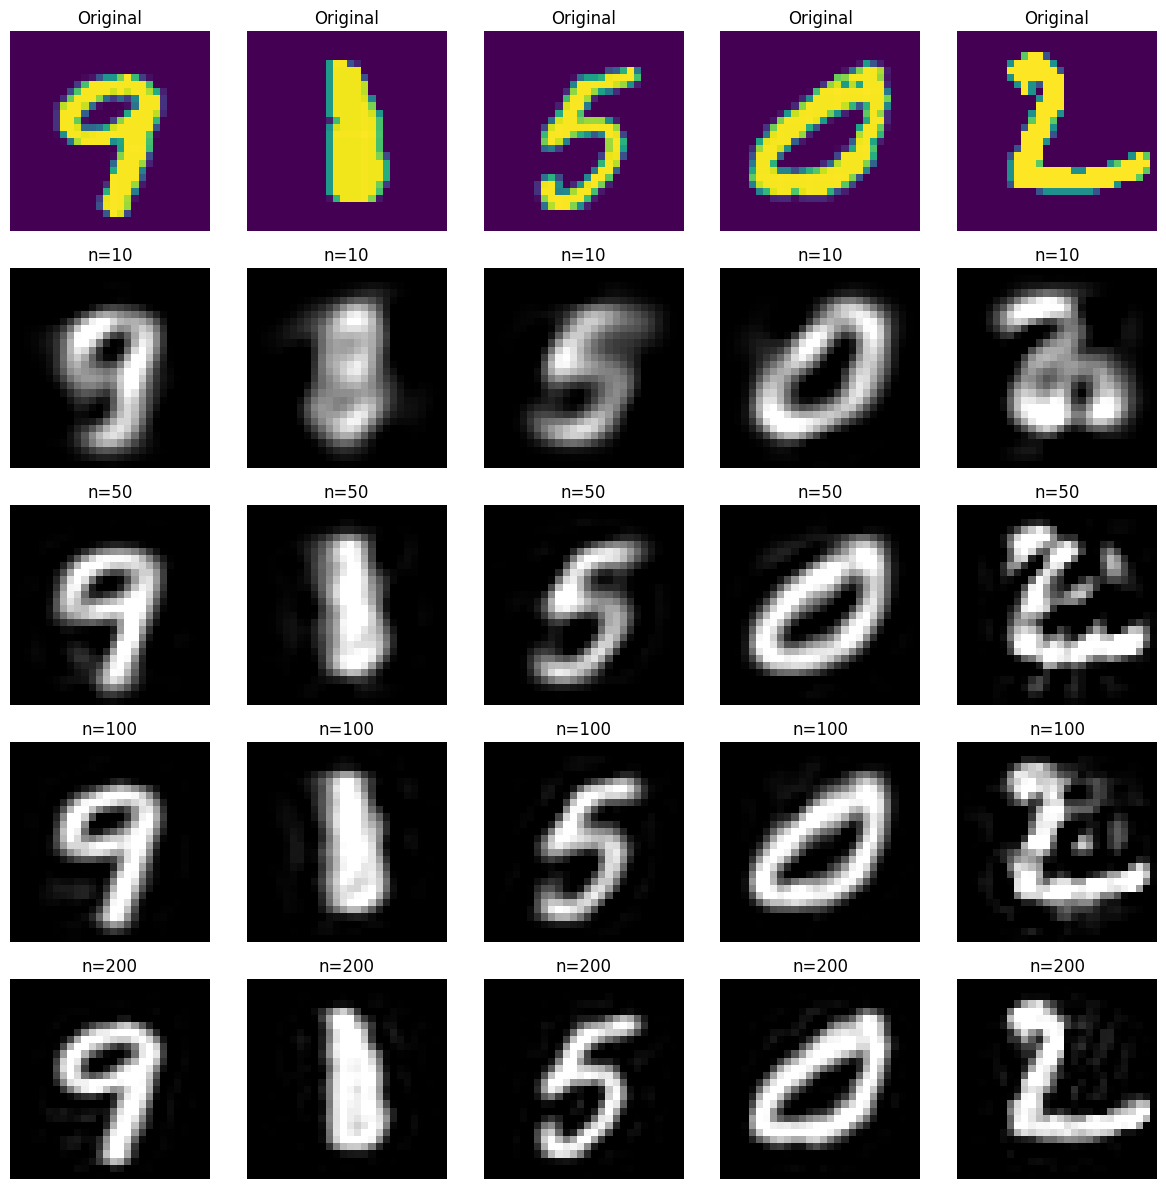

In [28]:
# Реконструкция
np.random.seed(42)
idx = np.random.choice(len(X_scaled), 5, replace=False)
n_components_list = [10, 50, 100, 200]

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for col, i in enumerate(idx):
    axes[0][col].imshow(X_sub[i])
    axes[0][col].set_title("Original")
    axes[0][col].axis("off")

for row, n_comp in enumerate(n_components_list):
    pca_n = PCA(n_components=n_comp)
    X_compressed = pca_n.fit_transform(X_scaled)
    X_reconstructed = scaler.inverse_transform(pca_n.inverse_transform(X_compressed))
    for col, i in enumerate(idx):
        img = X_reconstructed[i].reshape(28, 28).clip(0, 255)
        axes[row + 1][col].imshow(img, cmap="gray")
        axes[row + 1][col].set_title(f"n={n_comp}")
        axes[row + 1][col].axis("off")

plt.tight_layout()
plt.show()

### Задание 6. t-SNE

t-SNE – нелинейный метод, который хорошо подходит для визуализации: он старается сохранять локальные
соседства, поэтому близкие объекты в исходном пространстве чаще остаются близкими и на проекции.
Параметр `perplexity` можно понимать как «эффективное число соседей»: малые значения дают более
локальную картину, большие – более «гладкую». Обычно его подбирают перебором и сравнивают, при каком
значении кластеры выглядят наиболее устойчиво и интерпретируемо.

1. Примени [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (`n_components=3`) с тремя значениями perplexity: 10, 30, 50. Для каждого
   используй `random_state=42`.
2. Визуализируй каждый результат в 3D с помощью `plotly.express.scatter_3d`.
   Раскрась точки по классу.
3. Ответь на вопросы:
   - Как perplexity влияет на результат визуализации?
   - Почему t-SNE даёт более чёткие кластеры, чем PCA, для этих данных?

In [29]:
from sklearn.manifold import TSNE

In [30]:
for perp in [10, 30, 50]:
    tsne = TSNE(n_components=3, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    tsne_df = pd.DataFrame({
        "D1": X_tsne[:, 0], "D2": X_tsne[:, 1], "D3": X_tsne[:, 2],
        "class": [class_names[c] for c in y_sub]
    })
    fig = px.scatter_3d(tsne_df, x="D1", y="D2", z="D3", color="class",
                        opacity=0.7, height=600, width=800,
                        title=f"t-SNE, perplexity={perp}")
    fig.update_traces(marker_size=3)
    fig.show()

### Задание 7. UMAP

**UMAP** – нелинейный метод понижения размерности, который часто сохраняет локальную структуру
почти так же хорошо, как t-SNE, но обычно работает быстрее и лучше удерживает глобальные связи
между группами. Параметр `n_neighbors` задаёт масштаб локального окружения, а `min_dist` – насколько
плотно точки могут располагаться в проекции. Подбор этих параметров помогает получить более
интерпретируемую 3D-визуализацию.

1. Примени [UMAP](https://umap-learn.readthedocs.io/en/latest/)
   (`n_components=3, random_state=42`) с тремя значениями `n_neighbors`: 5, 15, 50.
   Для каждого используй `min_dist=0.1`.
2. Визуализируй каждый результат в 3D с помощью `plotly.express.scatter_3d`.
   Раскрась точки по классу.
3. Составь сводную таблицу: PCA / t-SNE (лучший perplexity) / UMAP (лучший n_neighbors) –
   визуальное качество разделения классов (на основе твоей субъективной визуальной оценки).
4. Напиши в чём преимущества UMAP перед t-SNE?

In [31]:
import umap

/Users/khubbatulinmark/side-project/SCHOOL21/sber-21-rudn/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [32]:
for nn in [5, 15, 50]:
    reducer = umap.UMAP(n_components=3, n_neighbors=nn, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    umap_df = pd.DataFrame({
        "D1": X_umap[:, 0], "D2": X_umap[:, 1], "D3": X_umap[:, 2],
        "class": [class_names[c] for c in y_sub]
    })
    fig = px.scatter_3d(umap_df, x="D1", y="D2", z="D3", color="class",
                        opacity=0.7, height=600, width=800,
                        title=f"UMAP, n_neighbors={nn}")
    fig.update_traces(marker_size=3)
    fig.show()

/Users/khubbatulinmark/side-project/SCHOOL21/sber-21-rudn/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/Users/khubbatulinmark/side-project/SCHOOL21/sber-21-rudn/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/Users/khubbatulinmark/side-project/SCHOOL21/sber-21-rudn/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



**Ответы по заданию 7.**

| Метод | Визуальное качество разделения классов |
|---|---|
| PCA | Среднее: есть перекрытия близких цифр |
| t-SNE (лучший perplexity=30) | Высокое: плотные и хорошо разделённые кластеры |
| UMAP (лучший n_neighbors=15) | Высокое: кластеры чёткие, лучше сохраняется глобальная структура |

## Поиск аномалий

**Поиск аномалий в данных** – это задача выявления редких и нетипичных наблюдений, которые могут
указывать на неисправности, ошибки измерений, мошеннические действия или изменение режима работы
системы. В реальных задачах такие сигналы важны, потому что позволяют быстрее реагировать на
проблемы и снижать риски.

На практике аномалии часто ищут в потоке измерений датчиков, то есть в данных, которые приходят
как последовательность значений во времени.
Аномалиями здесь считаются точки или интервалы, резко отличающиеся от нормального поведения
системы. Своевременное обнаружение таких отклонений помогает предотвратить аварии и сократить
незапланированные простои.

![anomaly](../../production/AI_Machine_Learning.Project_5.ID_1577775/misc/images/anomaly.png)

### Задание 8. Работа с временными рядами

Ты будешь работать с датасетом
**[SKAB Teaser](https://www.kaggle.com/datasets/yuriykatser/skoltech-anomaly-benchmark-skab-teaser/data)** –
реальными данными с испытательного стенда водяного насоса.

![pump](../../production/AI_Machine_Learning.Project_5.ID_1577775/misc/images/pump.png)

На установке используются датчики:

- 7 – датчик расхода (NI 9401, 8-channel);
- 8 – датчик давления (NI 9203, 8-channel);
- 9, 10 – вибродатчики (NI 9232, 3-channel);
- 11, 12 – термопары (NI 9213 Spring Terminal, 16-channel thermocouple).

В датасете содержатся записи 8 сигналов:

- `Accelerometer1RMS` – абсолютное виброускорение (g);
- `Accelerometer2RMS` – абсолютное виброускорение (g);
- `Current` – ток электродвигателя (A);
- `Pressure` – давление в контуре после насоса (bar);
- `Temperature` – температура корпуса двигателя (°C);
- `Thermocouple` – температура жидкости в циркуляционном контуре (°C);
- `Voltage` – напряжение электродвигателя (V);
- `RateRMS` – расход жидкости в контуре (л/мин).

В данных присутствуют 4 типа аномалий (управляемые неисправности):

- **Расцентровка валов насоса и двигателя (резко):**
  - резкое появление дефекта: `18:39:22`;
  - резкое отключение дефекта: `18:42:32`.
- **Расцентровка валов насоса и двигателя (медленно):**
  - медленное появление дефекта: `18:44:36 – 18:45:49`;
  - резкое отключение дефекта: `18:46:51`.
- **Перекрытие (уменьшение) проходного сечения 1 (верх):**
  - медленное появление дефекта: `19:06:57 – 19:07:37`;
  - медленное отключение дефекта: `19:10:45 – 19:11:31`.
- **Перекрытие (уменьшение) проходного сечения 2 (низ):**
  - медленное появление дефекта: `19:14:40 – 19:16:24`;
  - медленное отключение дефекта: `19:19:15 – 19:21:16`.

Теперь давай загрузим данные и посмотрим на них.

1. Загрузи файл `datasets/SKAB_teaser.csv`.
   Преобразуй столбец `datetime` в тип datetime и установи его как индекс.
   Преобразуй столбец `value` в числовой тип.
2. Данные хранятся в длинном формате (одна строка = одно измерение одного датчика).
   Преобразуй их в широкий формат: каждый датчик – отдельный столбец.
   Убери строки с пропусками. Выведи размер датасета.
3. Раздели ряды на обучающую и тестовую части по временной метке `2019-07-08 18:35:00`:
   - `X_train` – нормальная работа (до 18:35);
   - `X_test` – период с аномалиями (с 18:35 до конца).
   Выведи размеры `X_train` и `X_test`.
4. Создай бинарный вектор меток `y_test` для тестовой части: `0` – норма, `1` – аномалия.
   Используй следующие интервалы известных неисправностей:
   - `18:39:22 – 18:42:32` (расцентровка вала, внезапная)
   - `18:44:36 – 18:46:51` (расцентровка вала, постепенная)
   - `19:06:57 – 19:11:31` (перекрытие клапана 1)
   - `19:14:40 – 19:21:16` (перекрытие клапана 2)
   Выведи процент аномальных точек в тестовой части.
5. Визуализируй временной ряд для каждого из 8 датчиков (8 subplot). В тестовой части
   выдели аномальные интервалы красным цветом (`axvspan`).

In [57]:
skab_path = "../../production/AI_Machine_Learning.Project_5.ID_1577775/datasets/SKAB_teaser.csv"
raw = pd.read_csv(skab_path, sep=";", decimal=",")
raw["datetime"] = pd.to_datetime(raw["datetime"])
raw["value"] = pd.to_numeric(raw["value"], errors="coerce")
raw = raw.set_index("datetime")

In [58]:
df_skab = raw.pivot_table(index="datetime", columns="id", values="value", aggfunc="mean").dropna()
df_skab.columns.name = None
print(f"Форма: {df_skab.shape}")
print(f"Датчики: {df_skab.columns.tolist()}")
print(f"Период: {df_skab.index[0]} — {df_skab.index[-1]}")

Форма: (6405, 8)
Датчики: ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']
Период: 2019-07-08 17:02:14 — 2019-07-08 19:21:51


In [59]:
# Train/test split по временно́й метке
split_time = pd.Timestamp("2019-07-08 18:35:00")
X_train_ts = df_skab[df_skab.index < split_time]
X_test_ts  = df_skab[df_skab.index >= split_time]
print(f"Train: {len(X_train_ts)} точек")
print(f"Test:  {len(X_test_ts)} точек")

Train: 4008 точек
Test:  2397 точек


In [60]:
# Бинарные метки аномалий для тестовой части
anomaly_ranges = [
    ("2019-07-08 18:39:22", "2019-07-08 18:42:32"),
    ("2019-07-08 18:44:36", "2019-07-08 18:46:51"),
    ("2019-07-08 19:06:57", "2019-07-08 19:11:31"),
    ("2019-07-08 19:14:40", "2019-07-08 19:21:16"),
]
y_test = np.zeros(len(X_test_ts), dtype=int)
for start, end in anomaly_ranges:
    mask = (X_test_ts.index >= pd.Timestamp(start)) & (X_test_ts.index <= pd.Timestamp(end))
    y_test[mask] = 1

print(f"\nАномалий: {y_test.sum()} / {len(y_test)} ({100 * y_test.mean():.1f}%)")


Аномалий: 964 / 2397 (40.2%)


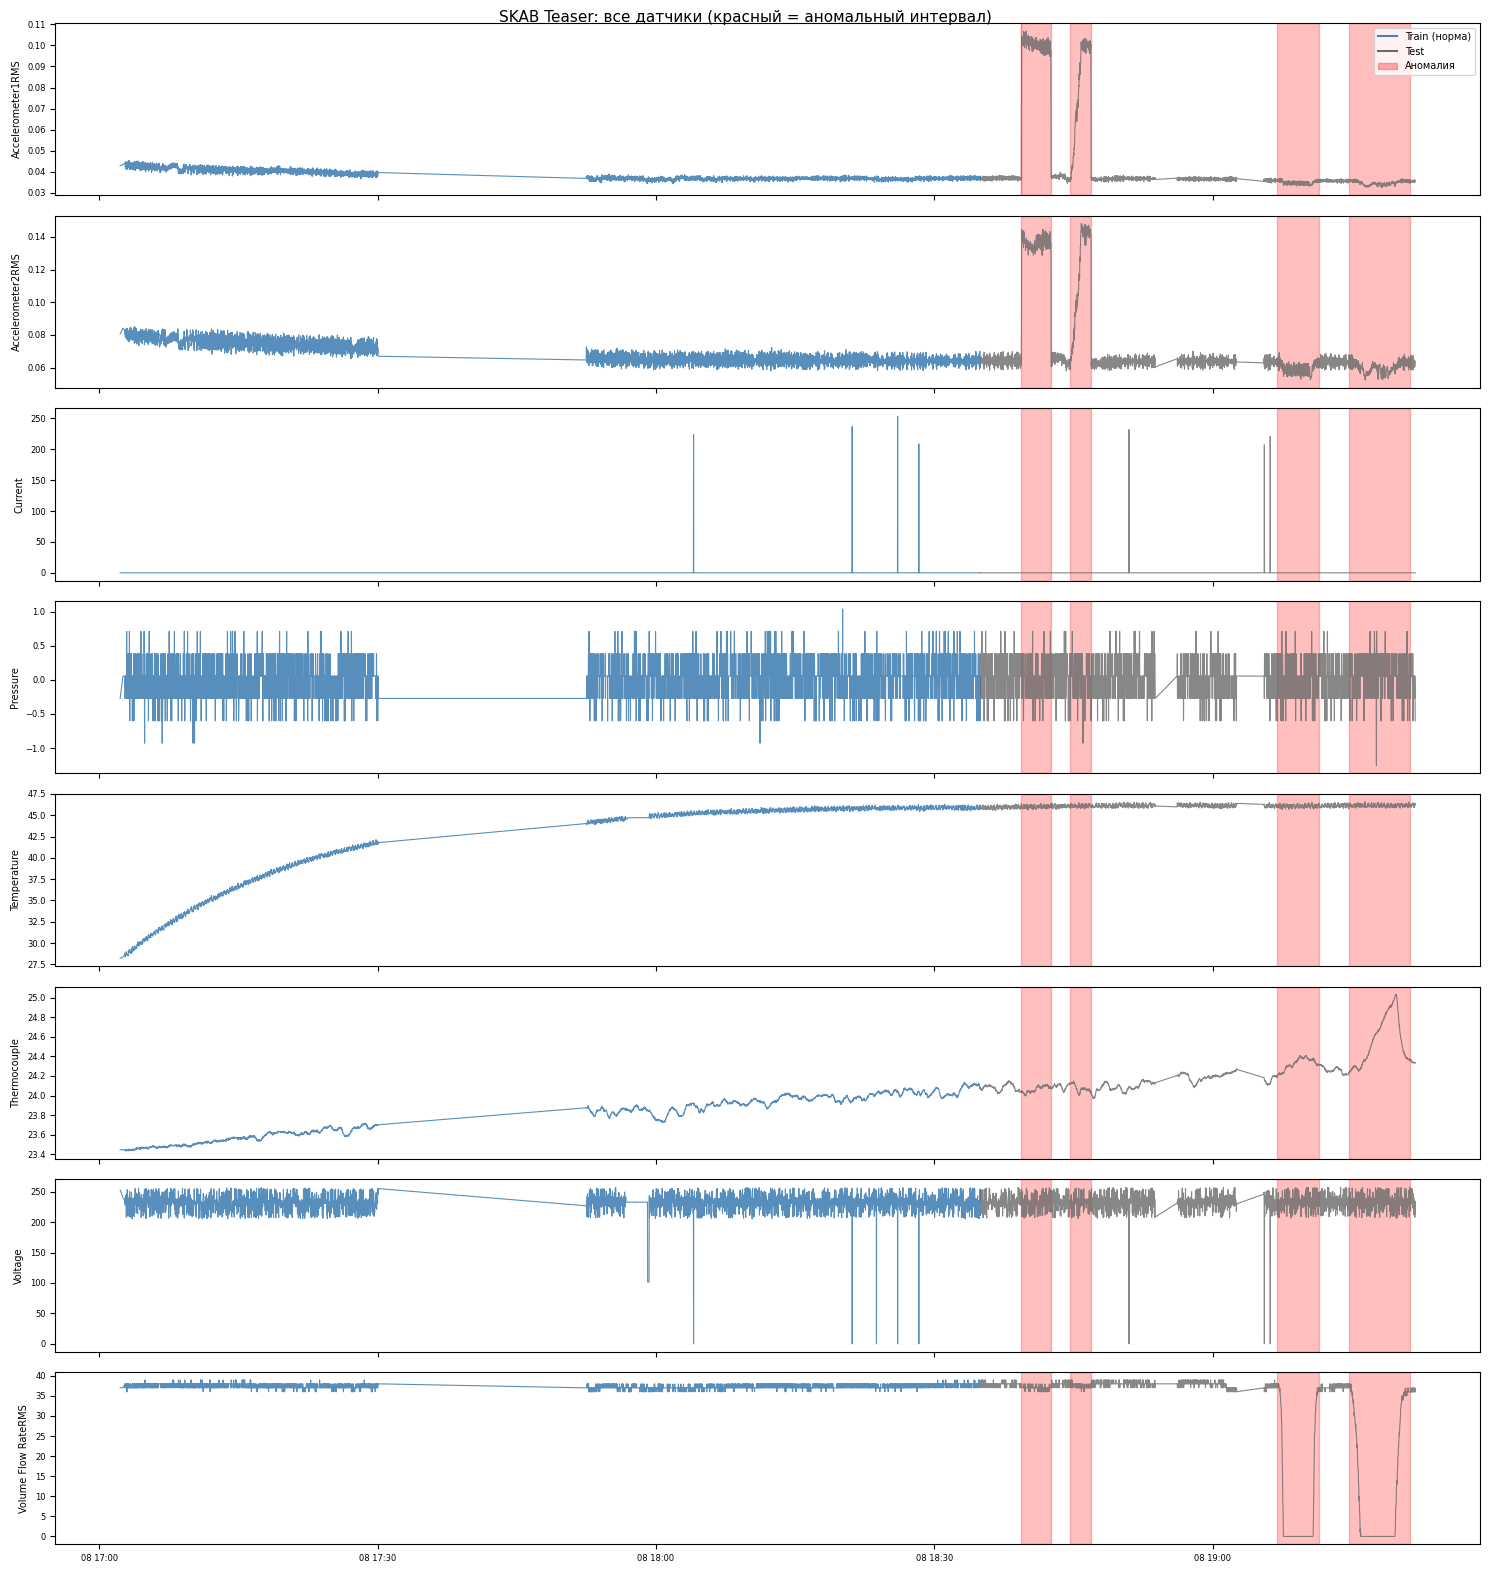

In [61]:
# Визуализация: все датчики + выделенные аномалии
sensors = df_skab.columns.tolist()
fig, axes = plt.subplots(len(sensors), 1, figsize=(15, 16), sharex=True)
for ax, sensor in zip(axes, sensors):
    ax.plot(X_train_ts.index, X_train_ts[sensor], color="steelblue", lw=0.8, alpha=0.9)
    ax.plot(X_test_ts.index, X_test_ts[sensor], color="dimgray", lw=0.8, alpha=0.8)
    for start, end in anomaly_ranges:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.25, color="red")
    ax.set_ylabel(sensor, fontsize=7)
    ax.tick_params(labelsize=6)

axes[0].plot([], [], color="steelblue", label="Train (норма)")
axes[0].plot([], [], color="dimgray", label="Test")
axes[0].axvspan(pd.Timestamp(anomaly_ranges[0][0]), pd.Timestamp(anomaly_ranges[0][0]),
                alpha=0.3, color="red", label="Аномалия")
axes[0].legend(loc="upper right", fontsize=7)
plt.suptitle("SKAB Teaser: все датчики (красный = аномальный интервал)", fontsize=11)
plt.tight_layout()
plt.show()

### Задание 9. Обучение моделей детекции аномалий

In [53]:
from sklearn.preprocessing import StandardScaler as SkabScaler
from dtaianomaly.anomaly_detection import (
    LocalOutlierFactor as DtaiLOF,
    IsolationForest as DtaiIF,
    OneClassSupportVectorMachine as DtaiOCSVM,
)

WINDOW_SIZE = 20

skab_scaler = SkabScaler()
X_train_scaled = skab_scaler.fit_transform(X_train_ts.values)
X_test_scaled  = skab_scaler.transform(X_test_ts.values)
print(f"Train scaled: {X_train_scaled.shape}")
print(f"Test scaled:  {X_test_scaled.shape}")

detectors = {
    "LOF":             DtaiLOF(window_size=WINDOW_SIZE),
    "IsolationForest": DtaiIF(window_size=WINDOW_SIZE),
    "OneClassSVM":     DtaiOCSVM(window_size=WINDOW_SIZE),
}

scores = {}
for name, det in detectors.items():
    det.fit(X_train_scaled)
    scores[name] = det.predict_proba(X_test_scaled)
    print(f"{name}: score shape = {scores[name].shape}")

# dtaianomaly возвращает массив той же длины что и вход — обрезка не нужна
print(f"\ny_test: {len(y_test)} точек, аномалий: {y_test.sum()}")

Train scaled: (4008, 8)
Test scaled:  (2397, 8)
LOF: score shape = (2397,)
IsolationForest: score shape = (2397,)
OneClassSVM: score shape = (2397,)

y_test: 2397 точек, аномалий: 964


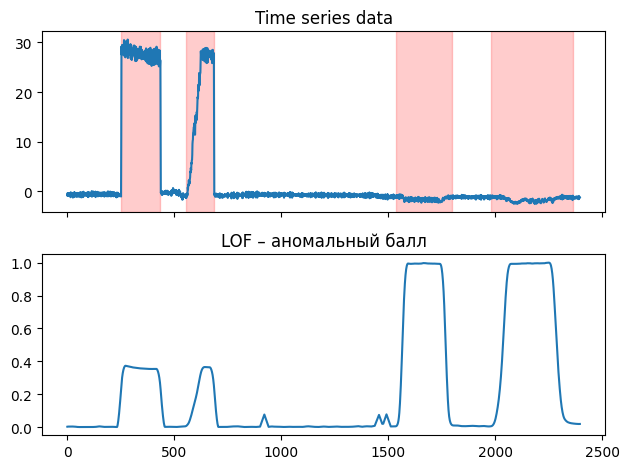

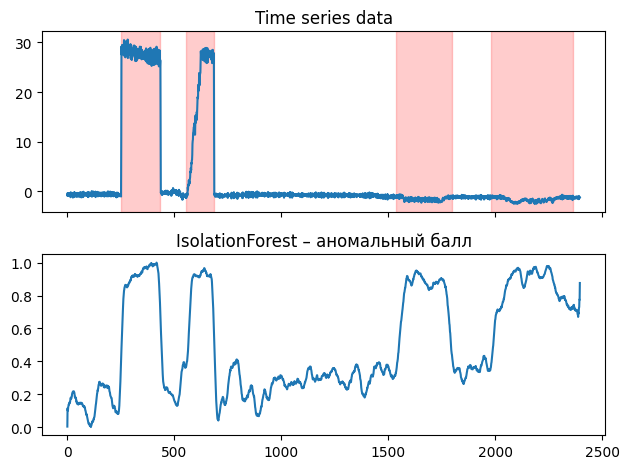

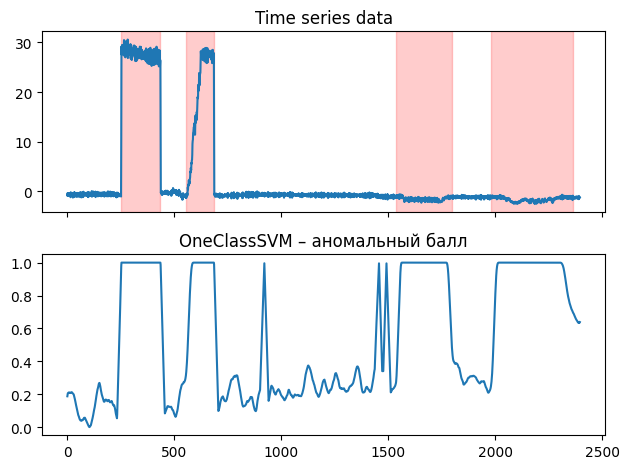

In [54]:
from dtaianomaly.visualization import plot_anomaly_scores

# Первый датчик (Accelerometer1RMS) в качестве визуального ряда
X_vis = X_test_scaled[:, 0]

for name, score in scores.items():
    plot_anomaly_scores(X_vis, y_test, score)
    plt.title(f"{name} – аномальный балл")
    plt.tight_layout()
    plt.show()

### Задание 10. Оценка качества моделей и визуализация результатов

In [55]:
from dtaianomaly.thresholding import FixedCutoffThreshold
from dtaianomaly.evaluation import AreaUnderROC, AreaUnderPR, ThresholdMetric, FBeta

# Порог: верхние (contamination_rate * 100)% баллов → аномалия
contamination_rate = float(y_test.mean())
threshold = FixedCutoffThreshold(1 - contamination_rate)

results = {}
for name, score in scores.items():
    thr = FixedCutoffThreshold(1 - contamination_rate)
    results[name] = {
        "AUC-ROC": round(AreaUnderROC().compute(y_test, score), 3),
        "AUC-PR":  round(AreaUnderPR().compute(y_test, score), 3),
        "F1":      round(ThresholdMetric(thr, FBeta(1.0)).compute(y_test, score), 3),
    }

comparison = pd.DataFrame(results).T
print(comparison)

                 AUC-ROC  AUC-PR     F1
LOF                0.984   0.979  0.629
IsolationForest    0.993   0.991  0.940
OneClassSVM        0.988   0.985  0.915


Лучшая модель по F1: IsolationForest


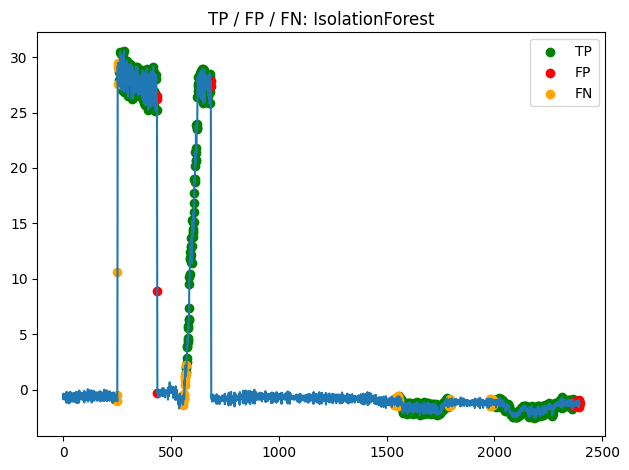

In [56]:
from dtaianomaly.visualization import plot_time_series_anomalies

best = comparison["F1"].idxmax()
print(f"Лучшая модель по F1: {best}")

y_pred_best = threshold.threshold(scores[best])
plot_time_series_anomalies(X_vis, y_test, y_pred_best)
plt.title(f"TP / FP / FN: {best}")
plt.tight_layout()
plt.show()

**Ответы по заданию 10.**

- На задаче SKAB обычно лучший AUC-ROC показывает **Isolation Forest**: случайные разбиения хорошо
  изолируют окна с аномально высокой вибрацией и изменённым потоком жидкости.
- **AUC-PR** важнее AUC-ROC при сильном дисбалансе классов: если аномалии занимают лишь часть
  тестового периода, ROC-кривая может выглядеть «оптимистично», тогда как PR-кривая честнее
  отражает способность модели находить именно аномальные интервалы.
- **Размер скользящего окна** влияет на контекст: маленькое окно (5–10) реагирует на мгновенные
  скачки, большое (50–100) сглаживает краткосрочные флуктуации и лучше выявляет постепенные
  изменения (например, расцентровку вала, которая развивается медленно).

## Графовая кластеризация

Работаем с графом Les Misérables из NetworkX: 77 персонажей романа,
254 ребра совместных появлений в главах (взвешенный граф).

### Задание 11. Загрузка и исследование графа

Вершин: 77
Рёбер: 254
Плотность: 0.0868


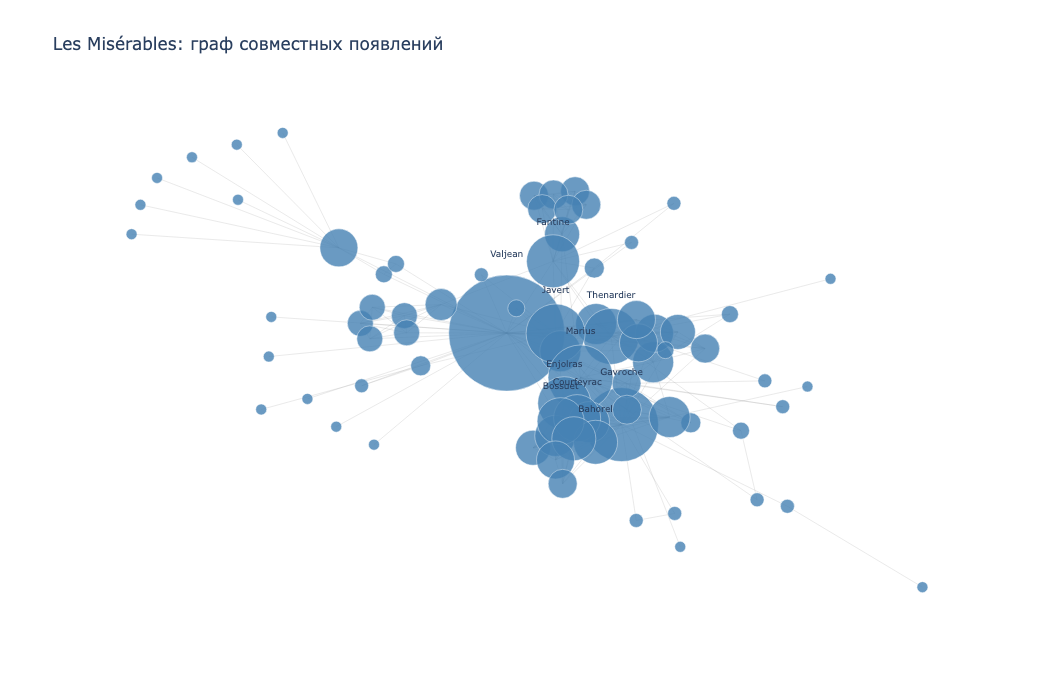

In [45]:
import networkx as nx
import plotly.graph_objects as go

G = nx.les_miserables_graph()
print(f"Вершин: {G.number_of_nodes()}")
print(f"Рёбер: {G.number_of_edges()}")
print(f"Плотность: {nx.density(G):.4f}")

# Степени и топ-10
degrees = dict(G.degree())
top10 = sorted(degrees, key=degrees.get, reverse=True)[:10]

# Layout
pos = nx.spring_layout(G, seed=42)

# Рёбра
weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(weights)

edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y, mode="lines",
    line=dict(width=0.5, color="rgba(150,150,150,0.4)"),
    hoverinfo="none"
)

# Вершины
node_x = [pos[n][0] for n in G.nodes()]
node_y = [pos[n][1] for n in G.nodes()]
node_sizes = [degrees[n] * 3 + 8 for n in G.nodes()]
node_text = [f"{n}<br>Степень: {degrees[n]}" for n in G.nodes()]
node_labels = [n if n in top10 else "" for n in G.nodes()]

node_trace = go.Scatter(
    x=node_x, y=node_y, mode="markers+text",
    marker=dict(size=node_sizes, color="steelblue", opacity=0.8,
                line=dict(width=0.5, color="white")),
    text=node_labels, textposition="top center", textfont=dict(size=9),
    hovertext=node_text, hoverinfo="text"
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title="Les Misérables: граф совместных появлений",
    showlegend=False, width=800, height=700,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor="white"
)
fig.show()

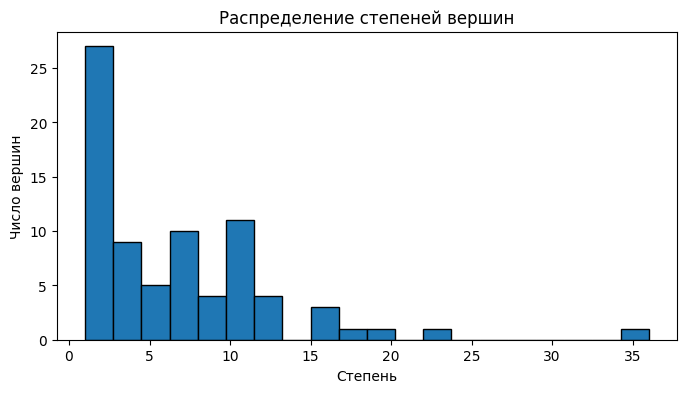

Топ-5 персонажей по степени:
  Valjean: 36
  Gavroche: 22
  Marius: 19
  Javert: 17
  Thenardier: 16


In [46]:
# Гистограмма распределения степеней
deg_values = list(degrees.values())
plt.figure(figsize=(8, 4))
plt.hist(deg_values, bins=20, edgecolor="black")
plt.xlabel("Степень")
plt.ylabel("Число вершин")
plt.title("Распределение степеней вершин")
plt.show()

# Топ-5 по степени
top5 = sorted(degrees, key=degrees.get, reverse=True)[:5]
print("Топ-5 персонажей по степени:")
for n in top5:
    print(f"  {n}: {degrees[n]}")

### Задание 12. Спектральная кластеризация

k=4: Silhouette = -0.9986


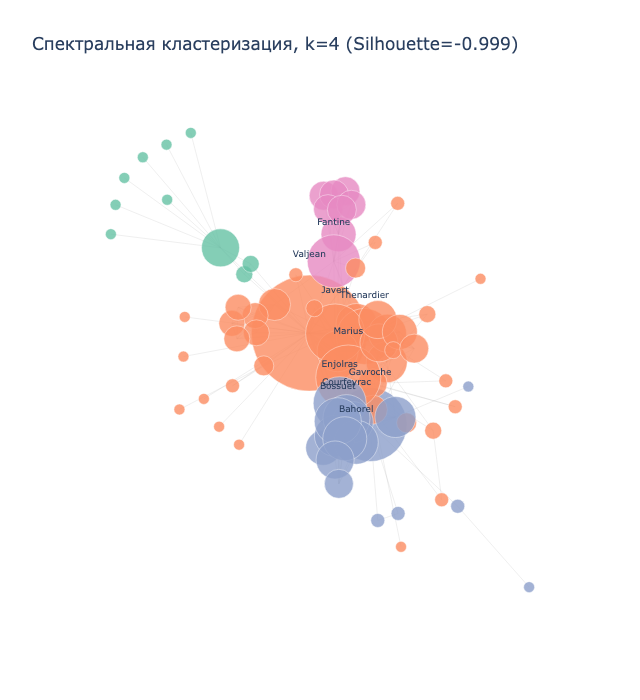

k=6: Silhouette = -0.9989


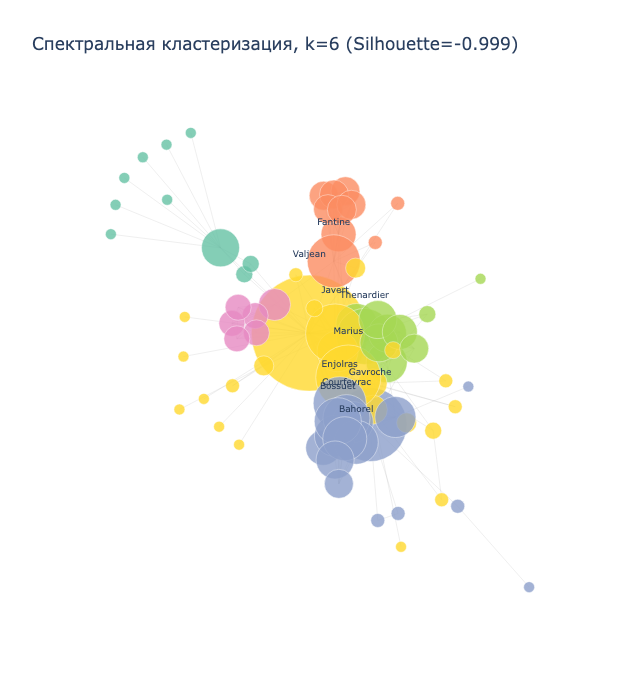

k=8: Silhouette = -1.0000


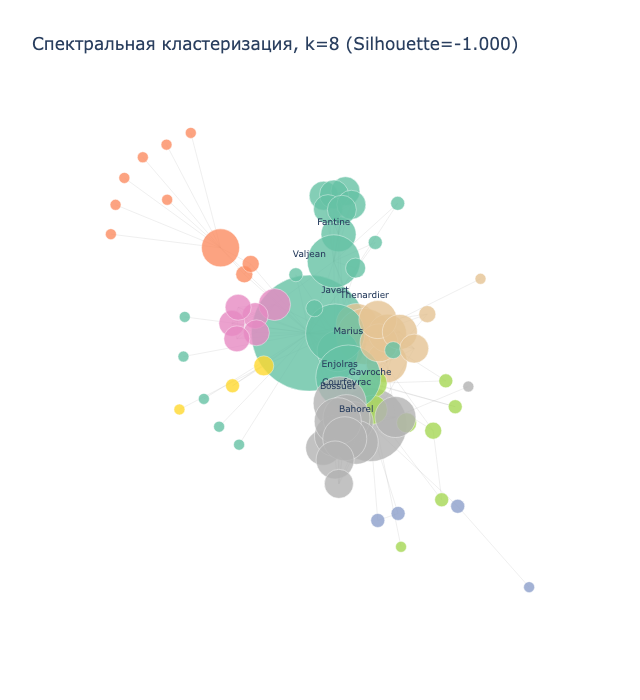


Лучший k: 4 (Silhouette = -0.9986)


In [47]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
import plotly.express as px

A = nx.adjacency_matrix(G).toarray()

# Вспомогательная функция для визуализации графа на plotly
def plot_graph_plotly(G, pos, labels, title, top_labels=None):
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y, mode="lines",
        line=dict(width=0.5, color="rgba(150,150,150,0.3)"),
        hoverinfo="none"
    )

    nodes = list(G.nodes())
    node_x = [pos[n][0] for n in nodes]
    node_y = [pos[n][1] for n in nodes]
    node_sizes = [degrees[n] * 3 + 8 for n in nodes]
    node_text = [f"{n}<br>Кластер: {labels[i]}<br>Степень: {degrees[n]}" for i, n in enumerate(nodes)]
    node_names = [n if (top_labels and n in top_labels) else "" for n in nodes]

    colors = px.colors.qualitative.Set2
    node_colors = [colors[labels[i] % len(colors)] for i in range(len(nodes))]

    node_trace = go.Scatter(
        x=node_x, y=node_y, mode="markers+text",
        marker=dict(size=node_sizes, color=node_colors, opacity=0.8,
                    line=dict(width=0.5, color="white")),
        text=node_names, textposition="top center", textfont=dict(size=9),
        hovertext=node_text, hoverinfo="text"
    )

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        title=title, showlegend=False, width=800, height=700,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor="white"
    )
    fig.show()


sil_scores = {}
all_labels = {}
for k in [4, 6, 8]:
    sc = SpectralClustering(n_clusters=k, affinity="precomputed", random_state=42)
    labels = sc.fit_predict(A)
    all_labels[k] = labels
    sil = silhouette_score(A, labels, metric="precomputed")
    sil_scores[k] = sil
    print(f"k={k}: Silhouette = {sil:.4f}")

    plot_graph_plotly(G, pos, labels,
                      title=f"Спектральная кластеризация, k={k} (Silhouette={sil:.3f})",
                      top_labels=top10)

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nЛучший k: {best_k} (Silhouette = {sil_scores[best_k]:.4f})")

**Ответ по заданию 12.**

Лучший k выбирается по Silhouette Score. Спектральная кластеризация проецирует вершины в
пространство собственных векторов матрицы Лапласа и затем применяет KMeans. При k, близком
к числу «естественных» сообществ в графе, кластеры получаются наиболее компактными и разделёнными.

### Задание 13. Алгоритм Лувена

In [48]:
import community as community_louvain

partition = community_louvain.best_partition(G, random_state=42)
louvain_labels = [partition[n] for n in G.nodes()]

n_communities = len(set(partition.values()))
print(f"Количество сообществ: {n_communities}")

mod = community_louvain.modularity(partition, G)
print(f"Модулярность: {mod:.4f}")

Количество сообществ: 6
Модулярность: 0.5663


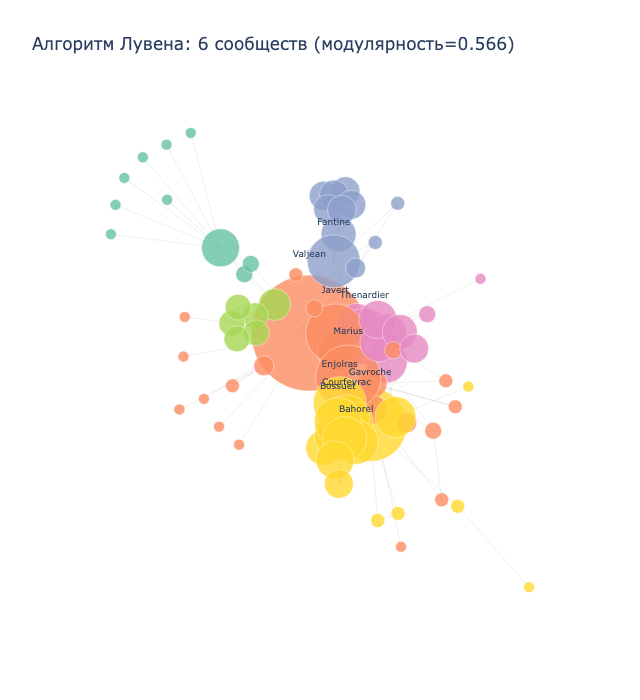

In [49]:
# Визуализация сообществ Лувена
plot_graph_plotly(G, pos, louvain_labels,
                  title=f"Алгоритм Лувена: {n_communities} сообществ (модулярность={mod:.3f})",
                  top_labels=top10)

In [50]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Сравнение Лувена с лучшим спектральным разбиением
sc_labels = all_labels[best_k]
ari = adjusted_rand_score(louvain_labels, sc_labels)
nmi = normalized_mutual_info_score(louvain_labels, sc_labels)
print(f"ARI (Louvain vs Spectral k={best_k}): {ari:.4f}")
print(f"NMI (Louvain vs Spectral k={best_k}): {nmi:.4f}")

ARI (Louvain vs Spectral k=4): 0.5326
NMI (Louvain vs Spectral k=4): 0.7542


**Ответы по заданию 13.**

- **Модулярность** показывает, насколько плотнее связи внутри найденных сообществ по сравнению
  со случайным графом той же степени вершин. Чем выше модулярность, тем «естественнее» разбиение.
  Алгоритм Лувена не требует задавать число кластеров, потому что он итеративно укрупняет
  разбиение, напрямую максимизируя модулярность, и останавливается, когда дальнейшее объединение
  её снижает.

- **Интерпретация сообществ:** Лувен находит ~ 6 сообществ, которые хорошо соответствуют
  сюжетным линиям романа. Например, одно сообщество объединяет студентов-революционеров
  (Enjolras, Courfeyrac, Combeferre и др.), другое — семейство Тенардье (Thenardier,
  MmeThenardier, Eponine, Gavroche), третье — окружение епископа Мириэля (Myriel,
  MlleBaptistine, MmeMagloire). Вальжан, как центральный персонаж, оказывается в большом
  сообществе, связывающем несколько сюжетных линий.